## ``Modern Portfolio Theory - Particle Swarm Algorithm``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import numpy as np
import pandas as pd
import pickle
import random
from datetime import timedelta
import time
from time import process_time
import matplotlib.pyplot as plt

In [2]:
# MASTER OF FUNDS + FUNDS NAVS + MARKET INDEX
def load_data(master, navs, index):
    '''
    Returns the data frame of the master of funds, the dictionary of funds NAVs and the data frame of market index series

    Parameters:
        master (string): Name of the master of funds file
        navs (string): Name of the funds NAVs file
        index (string): Name of the index file

    Return:
        df_master (DataFrame): Master of funds
        dict_navs (Dict): NAVs of funds
        df_index (DataFrame): Market index time series

    '''

    # Master of funds
    df_master = pd.read_csv(master, parse_dates = True, index_col = 0)

    # Funds NAVs
    with open(navs, 'rb') as handle:
        dict_navs = pickle.load(handle)

    # Index
    df_index = pd.read_csv(index, index_col = 0, sep = ';')
    df_index.index = df_index.index.str.replace('/', '-')
    df_index.index = pd.to_datetime(df_index.index, format = '%d-%m-%Y', errors = 'coerce')
    df_index.dropna(inplace = True)
    
    return df_master, dict_navs, df_index

In [3]:
# MASTER OF FUNDS + FUNDS NAVS + MARKET INDEX
df_master, dict_navs, df_index = load_data(master = '../data/data_ParticleSwarm/maestro.csv', navs = '../data/data_ParticleSwarm/navs.pickle', index = '../data/data_ParticleSwarm/MSCI.csv')

In [4]:
# FUNDS HOMOGENIZATION
def funds_homogenization(dict_navs, df_index):
    '''
    Returns the homogenization of a given dictionary of funds NAVs

    Parameters:
        dict_navs (Dict): NAVs of funds
        df_index (DataFrame): Market index time series

    Return:
        dict_navs (Dict): NAVs of funds homogenized

    '''

    # Loop
    dates = df_index.index
    for key in list(dict_navs.keys()):

        # Dates homogenization
        df_fund_i = dict_navs[key]
        df_hm = pd.DataFrame(index = dates)
        df_hm = df_hm.join(df_fund_i)
        dict_navs[key] = df_hm

    return dict_navs

In [5]:
# FUNDS HOMOGENIZATION
dict_navs = funds_homogenization(dict_navs = dict_navs, df_index = df_index)

In [6]:
# FUNDS NA ANALYSIS
def fund_na_analysis(dict_navs, p_na, window):
    '''
    Returns the NA analysis for a given given dictionary of funds NAVs 
        1) Dismiss the funds whose percentage of NA values exceed the given threshold on a time-window
        2) Fill the remaining NA values with previous or next data

    Parameters:
        dict_navs (Dict): NAVs of funds
        p_na (float): NA threshold
        window (int): Time-window

    Return:
        dict_navs (Dict): NAVs of funds

    '''

    # Loop
    for key in list(dict_navs.keys()):

        # Time-window
        df_fund_i = dict_navs[key].tail(window).copy()

        # If NA (by fund) > p_na * window, dismiss fund
        if df_fund_i.nav.isna().sum() > p_na * window:
            del dict_navs[key]

        # Fill remaining NA values with previous or next data
        else:
            df_fund_i.fillna(method = 'ffill', inplace = True)
            df_fund_i.fillna(method = 'bfill', inplace = True)
            dict_navs[key] = df_fund_i
    
    return dict_navs

In [7]:
# FUNDS NA ANALYSIS
dict_navs = fund_na_analysis(dict_navs = dict_navs, p_na = 0.20, window = 250)

In [8]:
# FUNDS (INDEPENDENT) RATIOS
def fund_ratio(dict_navs, df_index, window = 250):
    '''
    Returns the Yield, Volatility, Sharpe ratio and Jensen Alpha for a given set of funds on a time-window

    Parameters:
        dict_navs (Dict): NAVs of funds
        df_index (DataFrame): Market index time series
        window (int): Time-window

    Return:
        df_fund_ratio (DataFrame): Yield, Volatility, Sharpe ratio and Jensen Alpha per fund

    '''

    # Loop
    fund_id = []
    yields = []
    vol = []
    sharpe_ratio = []
    alpha_jensen = []
    for key, value in dict_navs.items():

        # Fund ID
        fund_id.append(value.allfunds_id.values[0])

        # Time-window
        value_window = value.tail(window)

        # Yield
        yield_i = np.log(value_window.nav) - np.log(value_window.nav.shift(1))
        yield_i = yield_i.iloc[1:]
        yields.append(yield_i.sum(axis = 0))

        # Volatility
        vol_i = yield_i.std(axis = 0)
        vol.append(vol_i)

        # Sharpe ratio
        if vol_i < 1.0e-2:
            sharpe_ratio.append(0)
        else:
            sharpe_ratio.append(yield_i.sum(axis = 0) / vol_i)

        # Index
        index_yield = np.log(df_index) - np.log(df_index.shift(1))
        index_yield = index_yield.iloc[1:,:]
        index_var = index_yield.var()[0]

        # Alpha ratio
        fund_index_cov = pd.concat([yield_i, index_yield], axis = 1).cov().iloc[0:-1, -1].values[0]
        if index_var == 0:
            alpha_jensen.append(yield_i.iloc[-1] - index_yield.iloc[-1].values[0])
        else:
            beta = fund_index_cov / index_var
            alpha_jensen.append(yield_i.iloc[-1] - beta * index_yield.iloc[-1].values[0])

    # Funds ratios
    df_fund_ratio = pd.DataFrame(columns = ['allfunds_id', 'Yield', 'Volatility', 'Sharpe_Ratio', 'Alpha_Jensen'])
    df_fund_ratio.allfunds_id = fund_id
    df_fund_ratio.Yield = yields
    df_fund_ratio.Volatility = vol
    df_fund_ratio.Sharpe_Ratio = sharpe_ratio
    df_fund_ratio.Alpha_Jensen = alpha_jensen

    return df_fund_ratio

In [9]:
# FUNDS (INDEPENDENT) RATIOS
df_fund_ratio = fund_ratio(dict_navs = dict_navs, df_index = df_index, window = 250)
df_fund_ratio.head(10)

,allfunds_id,Yield,Volatility,Sharpe_Ratio,Alpha_Jensen
0,90.0,0.290603,0.014705,19.76234,-0.011009
1,541.0,0.329932,0.011996,27.50263,-0.002922
2,909.0,0.020762,0.003514,0.00000,-0.000125
3,915.0,-0.020203,0.004895,0.00000,0.001069
4,922.0,-0.027512,0.004886,0.00000,0.001197
5,1625.0,0.009960,0.000526,0.00000,-0.000007
6,1626.0,0.010897,0.000512,0.00000,-0.000014
7,1905.0,0.279744,0.014678,19.05860,-0.012079
8,3395.0,0.070853,0.003455,0.00000,-0.000149
9,6214.0,0.036063,0.001063,0.00000,0.000848


In [10]:
# ELITE POPULATION FUNDS - OBJECTIVE FUNCTION
def elite_fund(df_fund_ratio, n_fund = 100, obj_fun = 2):
    '''
    Returns the elite population of the best (n_fund) funds for the objetive function (obj_fun):
        [0] Maximize Yield
        [1] Minimize Risk
        [2] Maximize Sharpe Ratio
        [3] Maximize Jensen Alpha

    Parameters:
        df_fund_ratio (DataFrame): Yield, Volatility, Sharpe ratio and Jensen Alpha per fund
        n_fund (int): Number of funds
        obj_fun (int): Objective function ID

    Return:
        df_elite_fund (DataFrame): Elite population of funds for the objective function

    '''

    # Dismiss funds whose volitality = 0.00 (strict), repeating prices
    df_elite_fund = df_fund_ratio[df_fund_ratio.Volatility != 0]

    # Objective function 0: Maximize Yield
    if obj_fun == 0:
        df_elite_fund = df_elite_fund.sort_values(by = 'Yield', ascending = False)
        df_elite_fund = df_elite_fund.head(n_fund)

    # Objective function 1: Minimize Risk
    elif obj_fun == 1:
        df_elite_fund = df_elite_fund.sort_values(by = 'Volatility', ascending = True)
        df_elite_fund = df_elite_fund.head(n_fund)

    # Objective function 2: Maximize Sharpe
    elif obj_fun == 2:
        df_elite_fund = df_elite_fund.sort_values(by = 'Sharpe_Ratio', ascending = False)
        df_elite_fund = df_elite_fund.head(n_fund)

    # Objective function 3: Maximize Alpha
    elif obj_fun == 3:
        df_elite_fund = df_elite_fund.sort_values(by = 'Alpha_Jensen', ascending = False)
        df_elite_fund = df_elite_fund.head(n_fund)

    return df_elite_fund

In [11]:
# ELITE POPULATION FUNDS - OBJECTIVE FUNCTION
df_elite_fund_yield = elite_fund(df_fund_ratio = df_fund_ratio, n_fund = 100, obj_fun = 0)
df_elite_fund_risk = elite_fund(df_fund_ratio = df_fund_ratio, n_fund = 100, obj_fun = 1)
df_elite_fund_sharpe = elite_fund(df_fund_ratio = df_fund_ratio, n_fund = 100, obj_fun = 2)
df_elite_fund_alpha = elite_fund(df_fund_ratio = df_fund_ratio, n_fund = 100, obj_fun = 3)

In [12]:
# PORTFOLIO EFFICIENCY - OBJECTIVE FUNCTION
def portolio_efficiency(dict_navs, df_elite_fund, weights, df_index, window = 120, obj_fun = 2):
    '''
    Returns the portfolio efficiency (financial ratio) for a given portfolio and weight distribution
    for the objetive function (obj_fun) on a time-window:
        [0] Maximize Yield
        [1] Minimize Risk
        [2] Maximize Sharpe Ratio
        [3] Maximize Jensen Alpha

    Parameters:
        dict_navs (Dict): NAVs of funds
        df_elite_fund (DataFrame): Elite population of funds for the objective function
        weights (DataFrame): Distribution of weights
        df_index (DataFrame): Market index time series
        window (int): Time-window
        obj_fun (int): Objective function ID

    Return:
        port_effcy (float): Portfolio efficiency for a given portfolio and weight distribution

    '''

    # Loop
    yields = []
    for key in df_elite_fund.allfunds_id:

        # Fund ID
        df_fund_i = dict_navs[key]

        # Time-window
        df_fund_i_window = df_fund_i.tail(window)

        # Yield
        yield_i = np.log(df_fund_i_window.nav) - np.log(df_fund_i_window.nav.shift(1))
        yield_i = yield_i.iloc[1:].tolist()
        yields.append(yield_i)

    # Covariance matrix
    mcov = pd.DataFrame(yields).T.cov().values

    # Portfolio Yield
    port_yield = weights @ df_elite_fund.Yield

    # Portfolio Risk
    port_risk = np.sqrt(weights @ mcov @ weights)

    # Portfolio Sharpe Ratio
    if port_risk < 1.0e-2:
        port_sharpe = 0
    else:
        port_sharpe = port_yield / port_risk

    # Index
    index_yield = np.log(df_index.tail(window)) - np.log(df_index.tail(window).shift(1))
    index_yield = index_yield.iloc[1:,:]
    index_var = index_yield.var()[0]

    # Portfolio Jensen Alpha
    fund_index_cov = pd.concat([pd.DataFrame(yields, columns = index_yield.index).T @ weights, index_yield], axis = 1).cov().iloc[0:-1, -1].values[0]
    if index_var == 0:
        port_alpha = port_yield - index_yield.sum(axis = 0).values[0]
    else:
        beta = fund_index_cov / index_var
        port_alpha = port_yield - index_yield.sum(axis = 0).values[0]

    # Portfolio Efficiency
    if obj_fun == 0:
        port_effcy = port_yield
    elif obj_fun == 1:
        port_effcy = -port_risk # min to max (obj_fun)
    elif obj_fun == 2:
        port_effcy = port_sharpe
    elif obj_fun == 3:
        port_effcy = port_alpha

    return port_effcy

In [13]:
# PARTICLE SWARM PORTFOLIO OPTIMIZATION
def ps_po(df_master, dict_navs, df_elite_fund, df_index, n_iter = 10, n_improv = 2, swarm_size = 100, n_fund = 100, obj_fun = 2):
    '''
    Returns the optimal portfolio for 1-worker resulting from applying the Particle Swarm AI algorithm over a set of 
    elite population funds for the objetive function:
        [0] Maximize Yield
        [1] Minimize Risk
        [2] Maximize Sharpe Ratio
        [3] Maximize Jensen Alpha
    The Particle Swarm IA algorithm deals with (n_iter) iterations per worker until optimal portfolio can be represented as a
    surface in an (swarm size)-dimensional space (particles) over the (n_funds) funds of the elite population. The algorithm iterates
    (n_iter) times or until the number of iterations without improvement exceeds a fixed threshold (n_improv). In each iteration, the 
    particles explore a (swarm size)-dimensional space to find the optimal portfolio over the (n_funds) of the elite population. 

    Parameters:
        df_master (DataFrame): Master of funds
        dict_navs (Dict): NAVs of funds
        df_elite_fund (DataFrame): Elite population of funds for the objective function
        df_index (DataFrame): Market index time series
        n_iter (int): Number of iterations per worker
        n_improv (int): Threshold of number of iterations without improvement
        swarm_size (int): Number of particles of the swarm
        n_fund (int): Number of funds
        obj_fun (int): Objective function ID

    Return:
        df_port (DataFrame): Evolution of the 
        max_effcy (float): Particle swarm portfolio optimization for a given worker specifications
        opt_port ():
        worker_yield (float): Particle swarm portfolio optimization for a given worker specifications

    '''

    # Random positions for particles in the swarm
    swarm_position = []
    for particle in range(swarm_size):
        position = [0] * n_fund
        for dimension in range(n_fund):
            position[dimension] = random.random()
        swarm_position.append(position)
    swarm_position = np.array([np.array(p) for p in swarm_position])

    # Random velocities for particles in the swarm
    swarm_velocity = []
    for particle in range(swarm_size):
        velocity = [0] * n_fund
        for dimension in range(n_fund):
            velocity[dimension] = random.random()
        swarm_velocity.append(velocity)
    swarm_velocity = np.array([np.array(v) for v in swarm_velocity])

    # Loop
    particles_best = swarm_position
    swarm_best = particles_best[0]
    port_effcy = []
    port_weights = []
    iter_i = 0
    improv_i = 0
    while (iter_i < n_iter) and (improv_i < n_improv):

        # Swarm loop
        best_effcy = []
        for particle in range(swarm_size):

            # Dimension loop
            for dimension in range(n_fund):

                # Random parameters
                r1 = random.random()
                r2 = random.random()
                w = (0.9 - 0.4) * ((n_iter - iter_i) / n_iter) + 0.4
                c1 = (0.5 - 2.5) * (iter_i / n_iter) + 2.5
                c2 = (2.5 - 0.5) * (iter_i / n_iter) + 0.5

                # Swarm velocity + Swarm position
                swarm_velocity[particle][dimension] = w * swarm_velocity[particle][dimension] + c1 * r1 * np.linalg.norm(particles_best[particle][dimension] - swarm_position[particle][dimension]) + c2 * r2 * np.linalg.norm(swarm_best[dimension] - swarm_position[particle][dimension])
                swarm_position[particle][dimension] = swarm_position[particle][dimension] + swarm_velocity[particle][dimension]

            # Optimal solution per dimension
            sharpe_best_i = portolio_efficiency(dict_navs, df_elite_fund, particles_best[particle], df_index, obj_fun = obj_fun)
            if portolio_efficiency(dict_navs, df_elite_fund, swarm_position[particle], df_index, obj_fun = obj_fun) > sharpe_best_i:
                particles_best[particle] = swarm_position[particle]
                sharpe_best_i = portolio_efficiency(dict_navs, df_elite_fund, particles_best[particle], df_index, obj_fun = obj_fun)
            best_effcy.append(sharpe_best_i)

        # Optimal solution per swarm
        if max(best_effcy) > portolio_efficiency(dict_navs, df_elite_fund, swarm_best, df_index, obj_fun = obj_fun):
            max_index = best_effcy.index(max(best_effcy))
            swarm_best = particles_best[max_index]
        else:
            improv_i += 1

        # Optimal solution per iteration
        port_effcy.append(portolio_efficiency(dict_navs, df_elite_fund, swarm_best, df_index, obj_fun = obj_fun))
        port_weights.append([w / sum(swarm_best) for w in swarm_best])
        iter_i += 1

    # Optimal solution per worker
    opt_port_evol = pd.DataFrame({'Portfolio_Efficiency': port_effcy, 'Weights': port_weights})
    max_effcy = opt_port_evol.Portfolio_Efficiency.max()
    opt_port = opt_port_evol.loc[opt_port_evol['Portfolio_Efficiency'] == max_effcy].Weights.values[0]
    df_opt_port = df_elite_fund[['allfunds_id']].copy()
    df_opt_port['Opt_Portfolio_Weights'] = opt_port
    df_opt_port = (df_opt_port
                   .sort_values(by = 'Opt_Portfolio_Weights', ascending = False)
                    .assign(Weights_cumsum = lambda x: x['Opt_Portfolio_Weights'].cumsum()))
    df_opt_port = (df_opt_port[(df_opt_port['Opt_Portfolio_Weights'] >= 0.01) | (df_opt_port['Weights_cumsum'] <= 0.50)])
    df_opt_port = df_opt_port.drop(columns = 'Weights_cumsum')
    end_iter = iter_i - 1

    return list(opt_port_evol.Portfolio_Efficiency), df_opt_port, end_iter

In [14]:
# PARTICLE SWARM PORTFOLIO OPTIMIZATION
n_worker = 1

# Timer starting
elapsed_time = time.time()
cpu_time = process_time()

# Maximize Portfolio Sharpe Ratio
opt_port_evol, df_opt_port, end_iter = ps_po(df_master = df_master, dict_navs = dict_navs, df_elite_fund = df_elite_fund_sharpe, df_index = df_index, n_iter = 20, n_improv = 10, swarm_size = 100, n_fund = 100, obj_fun = 2)

# Timer ending
cpu_time = process_time() - cpu_time
elapsed_time = time.time() - elapsed_time
print('Process-CPU time = ' + str(timedelta(seconds = cpu_time)))
print('Elapsed-Real time = ' + str(timedelta(seconds = elapsed_time)))

Process-CPU time = 0:19:11.870761
Elapsed-Real time = 0:03:19.533020


PARTICLE SWARM PORTFOLIO OPTIMIZATION - OPTIMAL PORTFOLIO
Iteration #11: 
 (*) Portfolio: 
        allfunds_id  Opt_Portfolio_Weights
6189      112047.0               0.024481
19126     202326.0               0.020713
16750     272483.0               0.019541
22644      92324.0               0.019467
13573     146486.0               0.019309
13575     146488.0               0.018560
5892       28318.0               0.016208
16518     176814.0               0.015899
3296       83725.0               0.014848
12648      94767.0               0.014551
20426     280748.0               0.014177
3300       83736.0               0.014049
22643      92323.0               0.013757
1515       86524.0               0.013374
3295       83724.0               0.013081
14968     404004.0               0.012894
2342       54442.0               0.012733
14404      59257.0               0.012703
13379      52221.0               0.012692
21397      42101.0               0.012629
13685     181391.0        

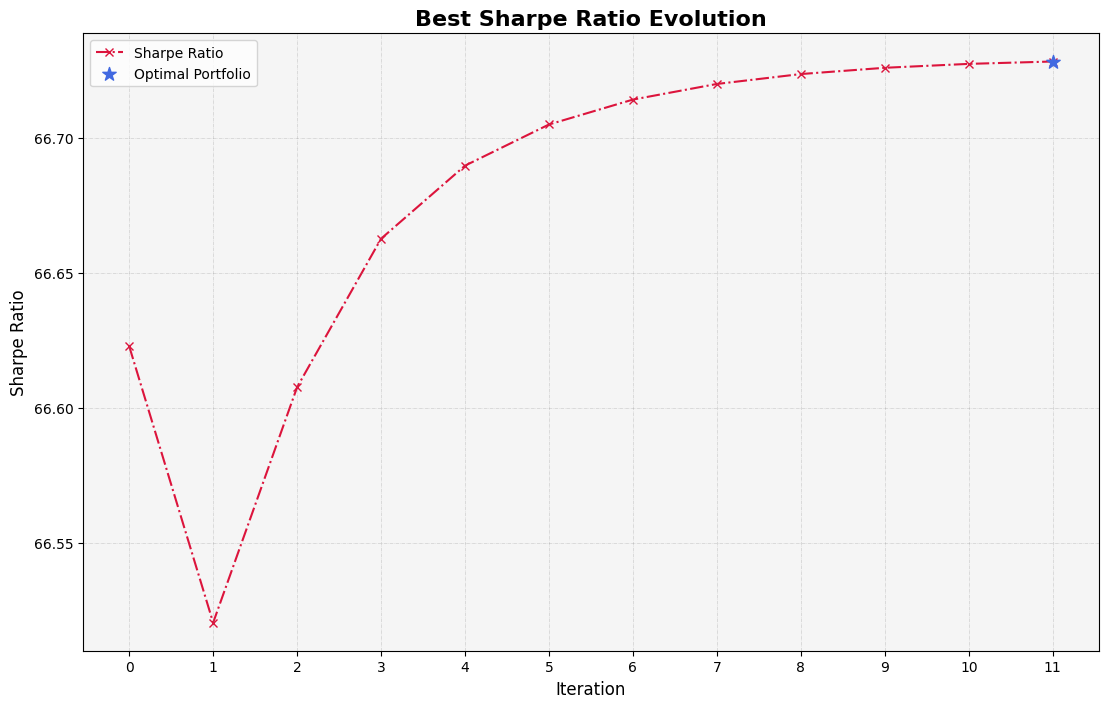

In [ ]:
# PARTICLE SWARM PORTFOLIO OPTIMIZATION - OPTIMAL PORTFOLIO
print(f'PARTICLE SWARM PORTFOLIO OPTIMIZATION - OPTIMAL PORTFOLIO')
print(f'Iteration #{end_iter}: \n (*) Portfolio: \n', df_opt_port)
fig, ax = plt.subplots(1, figsize = (12, 8))
ax.plot(opt_port_evol, label = 'Sharpe Ratio', color = 'crimson', marker = 'x', linestyle = '-.', zorder = 1)
ax.scatter([end_iter], [np.max(opt_port_evol)], label = 'Optimal Portfolio', color = 'royalblue', marker = '*', s = 102, zorder = 2)
ax.set_facecolor('whitesmoke')
plt.xticks(range(end_iter + 1), np.arange(0, end_iter + 1))
plt.title(label = 'Best Sharpe Ratio Evolution', fontsize = 16, fontweight = 'bold')
plt.xlabel('Iteration', fontsize = 12)
plt.ylabel('Sharpe Ratio', fontsize = 12)
plt.grid(visible = True, color = 'grey', linestyle = '-.', linewidth = 0.4, alpha = 0.4)
plt.tight_layout(pad = 4.0)
plt.legend(fontsize = 10)
#fig.savefig('../res/ParticleSwarmOptimalPortfolio.jpg')
plt.show()